# Practice quiz: Additional Neural Network Concepts

## Question 1

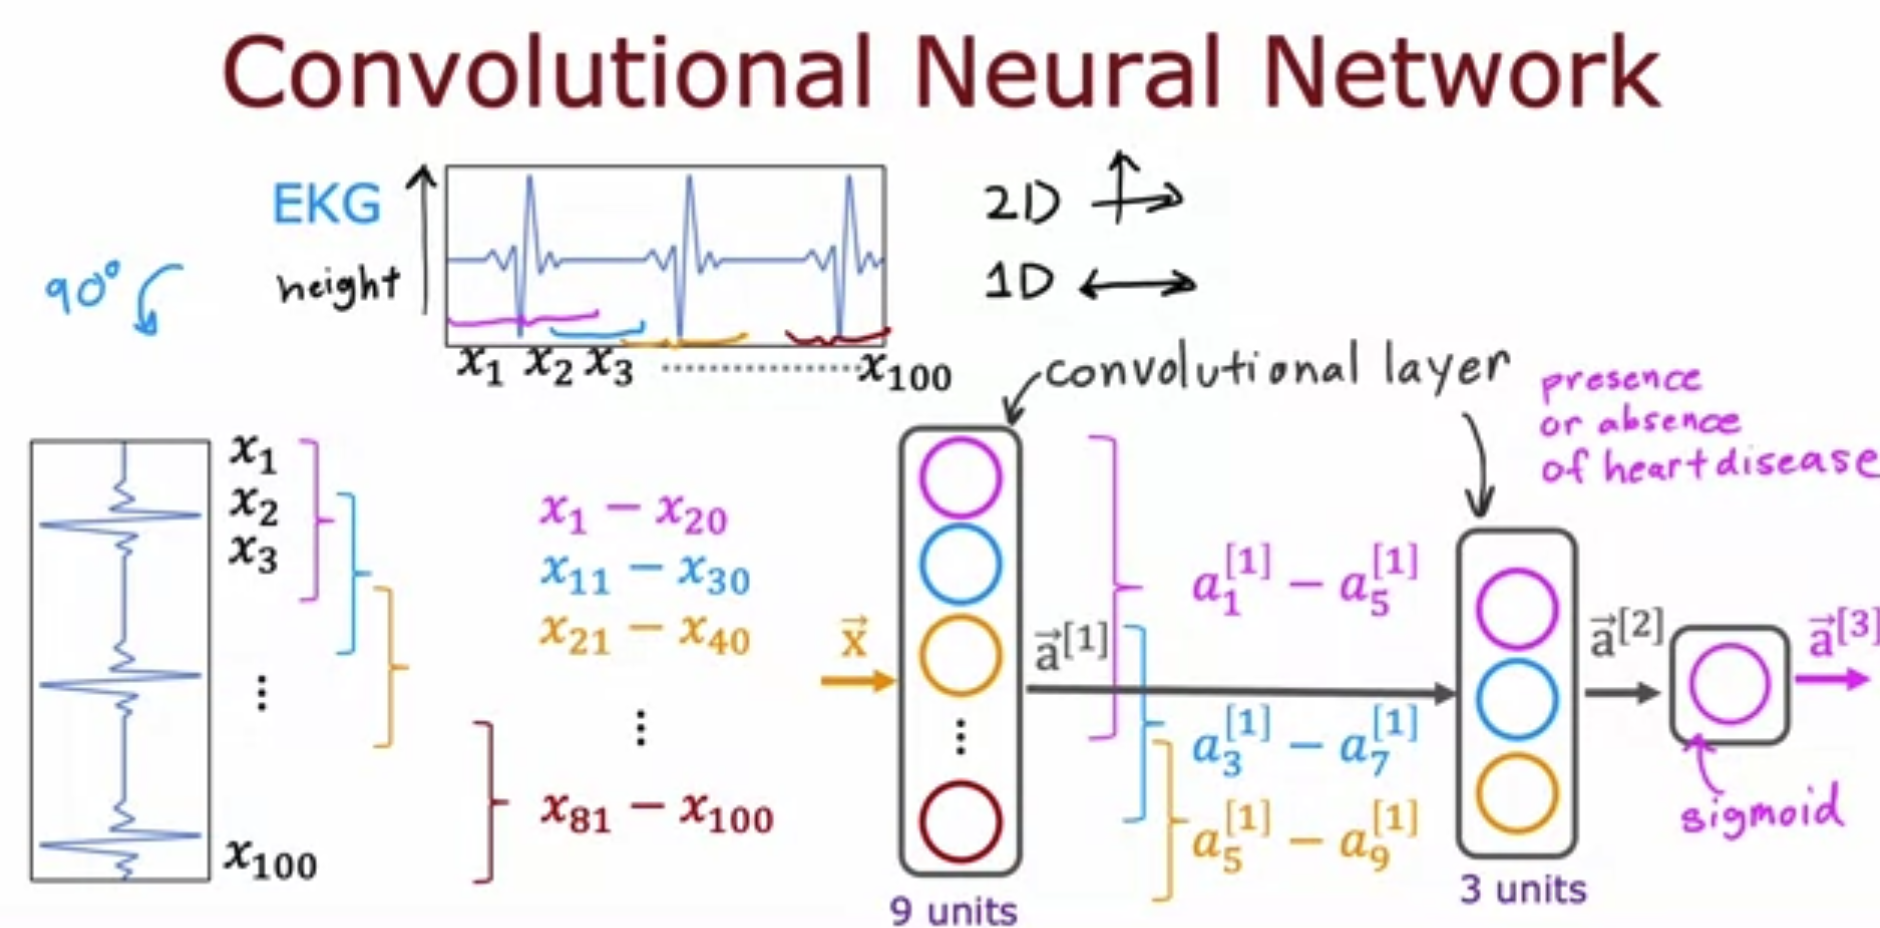

**The lecture covered a different layer type where each single neuron of the layer does not look at all the values of the input vector that is fed into that layer. What is this name of the layer type discussed in lecture?**

- [ ] convolutional layer
- [ ] A fully connected layer
- [ ] 1D layer or 2D layer (depending on the input dimension)
- [ ] Image layer

### Correct Answer Identification
- ✅ **convolutional layer**

### Explanation of Correct Answer

A **convolutional layer** is characterized by **local connectivity** - each neuron only looks at a small region of the input (called the **receptive field** or **filter**), rather than the entire input.

Key characteristics of convolutional layers:
- **Local connectivity:** Each neuron connects to only a small patch of the input
- **Weight sharing:** The same filter weights are used across different positions
- **Sparse interactions:** Most neurons in the layer don't interact with most of the input

This is in contrast to fully connected layers where every neuron connects to every input.

### Why This Matters

Convolutional layers are designed to exploit **spatial structure** in data:

For an image input $x_1, x_2, ..., x_{100}$ (flattened representation):
- A fully connected neuron would look at all 100 pixels
- A convolutional neuron might look at only $x_1, x_2, x_3$ (a small 3-pixel window)

The image shows both 1D convolutions (for sequential data) and 2D convolutions (for images), but the key principle is the same - **local receptive fields**.

### Explanation of Incorrect Options

#### ❌ A fully connected layer
- This is the **opposite** of what the question describes
- In fully connected (dense) layers, **every neuron connects to every input**
- Also called "dense" layers in TensorFlow/Keras

#### ❌ 1D layer or 2D layer
- These terms describe the **dimensionality** of the input, not the layer type
- A 1D convolutional layer is still a convolutional layer, just applied to 1D data
- The layer type is "convolutional", the "1D" or "2D" specifies the input format

#### ❌ Image layer
- This is not a standard neural network layer type
- "Image" describes the data modality, not the layer architecture
- Images can be processed by various layer types (convolutional, pooling, fully connected)

### Real-World Examples

**Convolutional Neural Networks (CNNs) in action:**

- **Facial recognition:** Early layers detect edges and simple patterns in small regions (e.g., 3×3 pixel patches). Later layers combine these to detect eyes, noses, and eventually entire faces.

- **Medical imaging:** CNNs analyze X-rays or MRI scans by first looking at small tissue regions, then combining information to detect tumors or abnormalities.

- **Self-driving cars:** Convolutional layers process camera images by detecting local features like lane markings, road edges, and pedestrians in specific image regions.

---

## Question 2

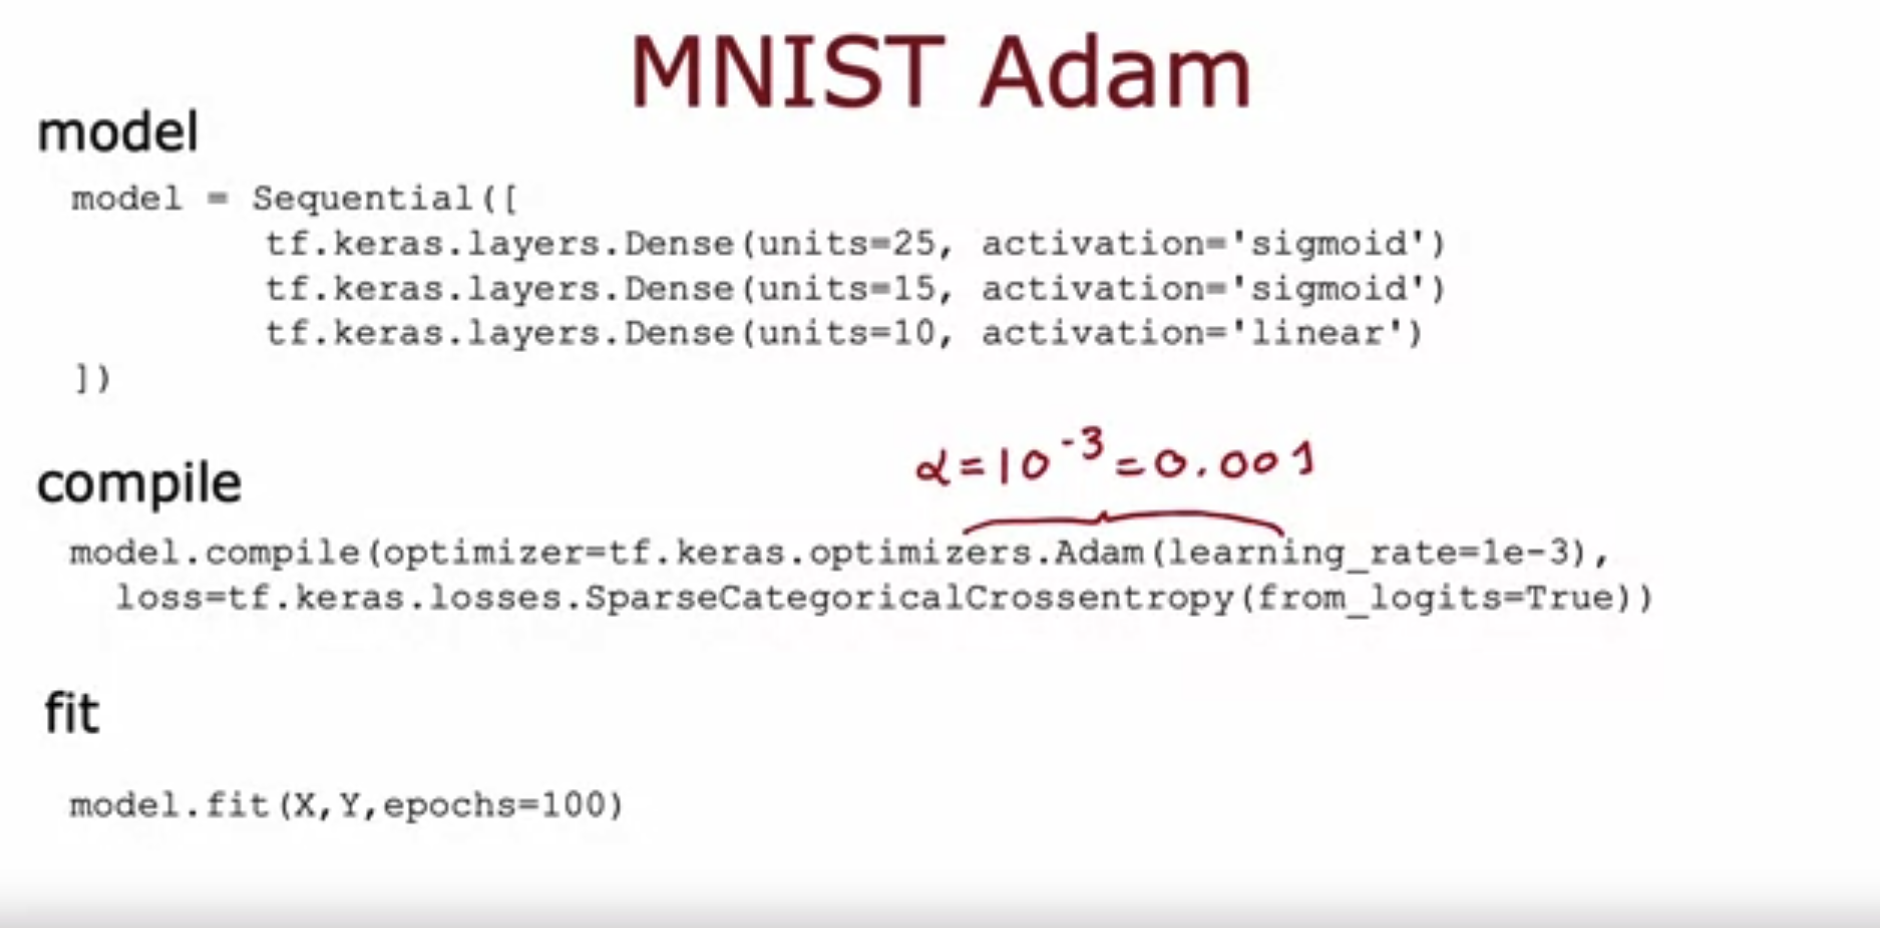

**The Adam optimizer is the recommended optimizer for finding the optimal parameters of the model. How do you use the Adam optimizer in TensorFlow?**

- [ ] When calling model.compile, set `optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)`.
- [ ] The call to model.compile() uses the Adam optimizer by default.
- [ ] The call to model.compile() will automatically pick the best optimizer, whether it is gradient descent, Adam or something else. So there's no need to pick an optimizer manually.
- [ ] The Adam optimizer works only with Softmax outputs. So if a neural network has a Softmax output layer, TensorFlow will automatically pick the Adam optimizer.

### Correct Answer Identification
- ✅ **When calling model.compile, set `optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)`.**

### Explanation of Correct Answer

To use the Adam optimizer in TensorFlow/Keras, you **explicitly specify it** when compiling the model:

```python
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)
```

The `learning_rate` parameter controls the step size during gradient descent:
- **Too large:** May overshoot the minimum
- **Too small:** Training becomes very slow
- **1e-3 (0.001)** is a common starting point for Adam

### What Makes Adam Special?

Adam (Adaptive Moment Estimation) combines benefits of two other optimizers:

1. **Momentum:** Helps accelerate convergence in relevant directions
2. **RMSProp:** Adapts learning rates for each parameter based on gradient magnitudes

This makes Adam:
- **Efficient:** Often requires less hyperparameter tuning
- **Adaptive:** Learning rates adjust automatically during training
- **Robust:** Works well for a wide range of problems

### Explanation of Incorrect Options

#### ❌ The call to model.compile() uses the Adam optimizer by default.
- **False.** The default optimizer in Keras is typically RMSprop or SGD (depending on the version)
- You must explicitly specify Adam if you want to use it

#### ❌ The call to model.compile() will automatically pick the best optimizer...
- **False.** There is no "automatic optimizer selection"
- Choosing the right optimizer is part of model design and requires understanding of the problem
- Different optimizers have different strengths and weaknesses

#### ❌ The Adam optimizer works only with Softmax outputs...
- **False.** Adam works with **any** output layer type:
  - Linear outputs (regression)
  - Sigmoid outputs (binary classification)
  - Softmax outputs (multiclass classification)
  - No activation function

### Real-World Analogy

Think of optimizers like different navigation strategies:

- **SGD (Stochastic Gradient Descent):** Like hiking straight downhill - simple but can get stuck
- **Momentum:** Like a ball rolling downhill - builds speed and rolls past small bumps
- **Adam:** Like an experienced hiker with:
  - A compass (momentum) showing direction history
  - An altimeter (adaptive learning) showing terrain steepness
  - Automatically adjusts step size based on both

### Common Optimizers Comparison

| Optimizer | Key Feature | Best For |
|-----------|------------|----------|
| **SGD** | Basic gradient descent | Simple problems, when you want interpretability |
| **SGD with Momentum** | Adds velocity term | Problems with ravines or noisy gradients |
| **Adam** | Adaptive learning rates + momentum | **Most problems (default choice)** |
| **RMSprop** | Adaptive learning rates | Recurrent neural networks |
| **Adagrad** | Parameter-specific learning rates | Sparse data (like NLP problems) |

### Complete Training Pipeline

```python
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# 1. Define model
model = Sequential([
    Dense(25, activation='relu'),
    Dense(15, activation='relu'),
    Dense(10, activation='linear')
])

# 2. Compile with Adam optimizer
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# 3. Train
history = model.fit(X_train, Y_train,
                    validation_data=(X_val, Y_val),
                    epochs=100)

# 4. Evaluate
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f"Test accuracy: {test_acc:.4f}")
```

---

## Summary Table: Layer Types and Optimizers

| Concept | Key Characteristic | TensorFlow Implementation |
|---------|-------------------|--------------------------|
| **Convolutional Layer** | Local connectivity, weight sharing | `tf.keras.layers.Conv2D()` |
| **Fully Connected Layer** | Every neuron connects to all inputs | `tf.keras.layers.Dense()` |
| **Adam Optimizer** | Adaptive learning + momentum | `tf.keras.optimizers.Adam()` |
| **Default Optimizer** | Varies by Keras version | Must specify explicitly |

**Key Takeaways:**
- **Convolutional layers** look at local patterns, making them efficient for spatially structured data like images
- **Adam** is the recommended default optimizer for most problems, but you must explicitly specify it
- Always set the `learning_rate` parameter when using Adam (1e-3 is a good starting point)